# Loan Approval Prediction

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder


from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
import joblib


## Data Loading 

In [33]:
df = pd.read_csv("loan_approval_data.csv")
df.head()

,ApplicantID,Age,Gender,Married,Dependent,Education,Self_Employed,Annual_Income,Loan_Amount_Lakhs,Loan_Term_Years,Credit_Score,Loan_Status
0,APP0001,39,Female,No,0,Graduate,No,4.4,19.3,15,588,Rejected
1,APP0002,33,Male,Yes,1,Not Graduate,No,10.1,40.0,25,753,Approved
2,APP0003,41,Male,No,1,Graduate,No,4.8,9.9,15,585,Approved
3,APP0004,50,Female,Yes,1,Graduate,No,5.9,41.1,10,641,Rejected
4,APP0005,32,Female,Yes,3,Graduate,No,6.1,41.5,25,590,Rejected


## Exploratory Data Analysis

In [34]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ApplicantID        500 non-null    object 
 1   Age                500 non-null    int64  
 2   Gender             500 non-null    object 
 3   Married            500 non-null    object 
 4   Dependent          500 non-null    int64  
 5   Education          500 non-null    object 
 6   Self_Employed      500 non-null    object 
 7   Annual_Income      500 non-null    float64
 8   Loan_Amount_Lakhs  500 non-null    float64
 9   Loan_Term_Years    500 non-null    int64  
 10  Credit_Score       500 non-null    int64  
 11  Loan_Status        500 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 47.0+ KB


ApplicantID          0
Age                  0
Gender               0
Married              0
Dependent            0
Education            0
Self_Employed        0
Annual_Income        0
Loan_Amount_Lakhs    0
Loan_Term_Years      0
Credit_Score         0
Loan_Status          0
dtype: int64

In [35]:
df.describe()

,Age,Dependent,Annual_Income,Loan_Amount_Lakhs,Loan_Term_Years,Credit_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,34.668000,1.018000,7.436400,35.944200,21.420000,698.56800
std,9.470647,0.981633,5.234129,28.244527,5.979558,63.27075
min,18.000000,0.000000,2.000000,5.000000,10.000000,493.00000
25%,27.750000,0.000000,4.200000,17.500000,15.000000,657.00000
50%,35.000000,1.000000,6.050000,27.900000,25.000000,700.50000
75%,41.000000,2.000000,8.925000,44.025000,25.000000,743.00000
max,65.000000,3.000000,50.000000,200.000000,30.000000,850.00000


## Visualizations

## Loan Status Distribution

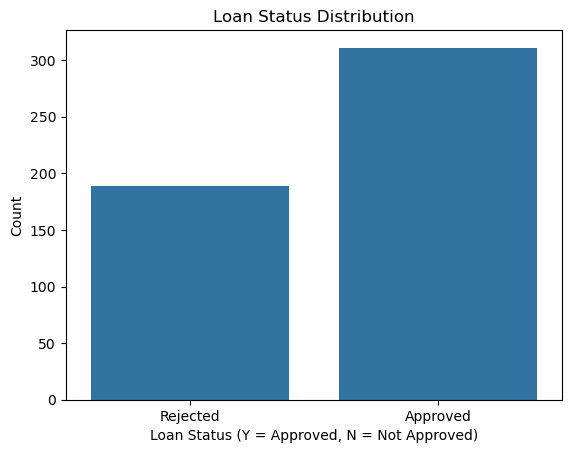

In [36]:
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status (Y = Approved, N = Not Approved)')
plt.ylabel('Count')
plt.show()


## Loan Status by Education Level

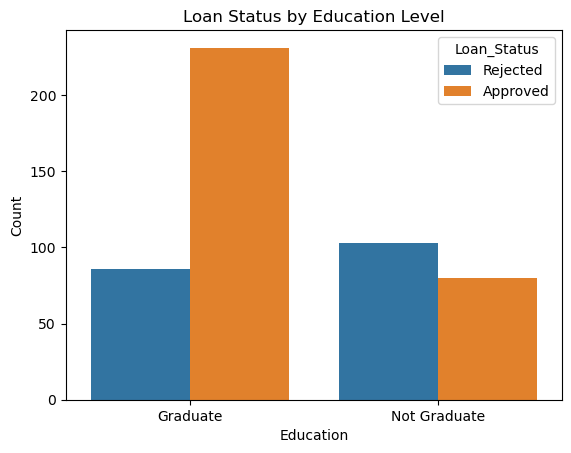

In [37]:
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title('Loan Status by Education Level')
plt.xlabel('Education')
plt.ylabel('Count')
plt.show()


## Loan Status by Gender

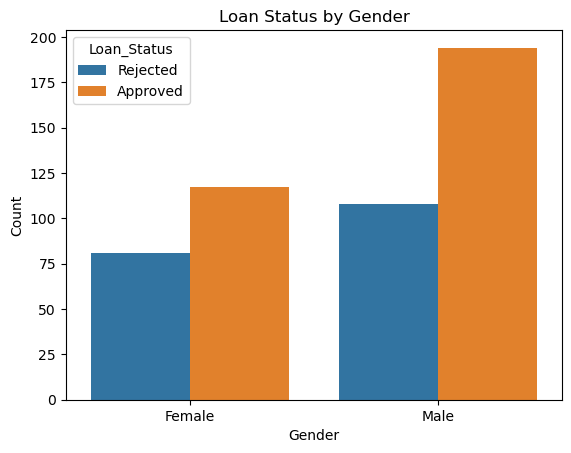

In [38]:
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.title('Loan Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


## Box Plots

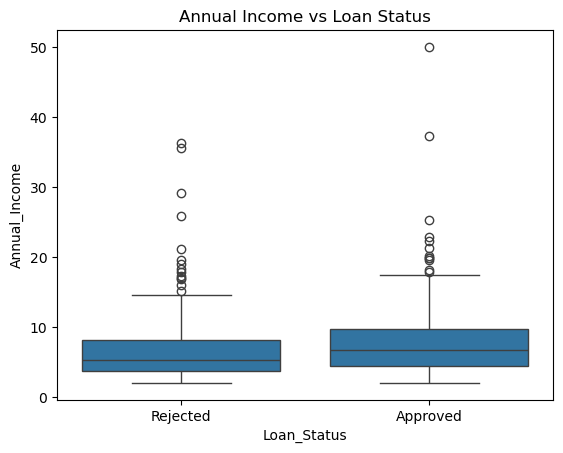

In [39]:
sns.boxplot(x='Loan_Status', y='Annual_Income', data=df)
plt.title("Annual Income vs Loan Status")
plt.show()

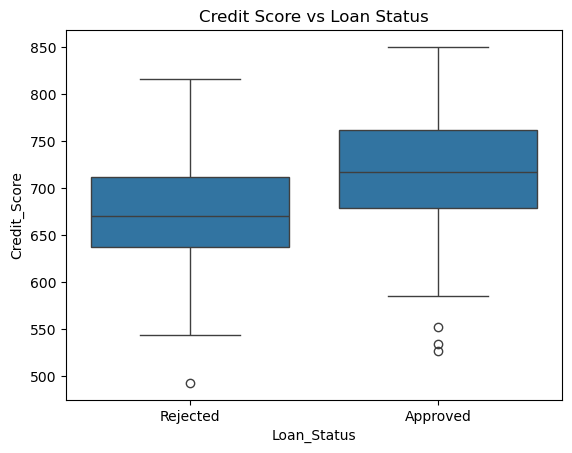

In [40]:
sns.boxplot(x='Loan_Status', y='Credit_Score', data=df)
plt.title("Credit Score vs Loan Status")
plt.show()


## Encode Categorical Columns

In [41]:
cat_cols = ['Gender', 'Married', 'Education','Self_Employed','Loan_Status']
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
df.head()

,ApplicantID,Age,Gender,Married,Dependent,Education,Self_Employed,Annual_Income,Loan_Amount_Lakhs,Loan_Term_Years,Credit_Score,Loan_Status
0,APP0001,39,0,0,0,0,0,4.4,19.3,15,588,1
1,APP0002,33,1,1,1,1,0,10.1,40.0,25,753,0
2,APP0003,41,1,0,1,0,0,4.8,9.9,15,585,0
3,APP0004,50,0,1,1,0,0,5.9,41.1,10,641,1
4,APP0005,32,0,1,3,0,0,6.1,41.5,25,590,1


In [42]:
df.drop('ApplicantID', axis=1, inplace=True)
df.head()

,Age,Gender,Married,Dependent,Education,Self_Employed,Annual_Income,Loan_Amount_Lakhs,Loan_Term_Years,Credit_Score,Loan_Status
0,39,0,0,0,0,0,4.4,19.3,15,588,1
1,33,1,1,1,1,0,10.1,40.0,25,753,0
2,41,1,0,1,0,0,4.8,9.9,15,585,0
3,50,0,1,1,0,0,5.9,41.1,10,641,1
4,32,0,1,3,0,0,6.1,41.5,25,590,1


## Data Splitting 

In [43]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Logistic Regression 

## Model Training

In [44]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

## Model Evaluation

Accuracy: 0.7
Confusion Matrix:
 [[46 12]
 [18 24]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.79      0.75        58
           1       0.67      0.57      0.62        42

    accuracy                           0.70       100
   macro avg       0.69      0.68      0.68       100
weighted avg       0.70      0.70      0.70       100



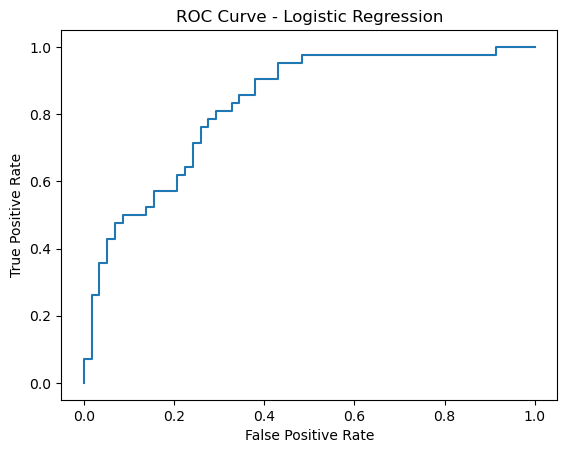

In [45]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.show()


## Decision Tree

In [46]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Classification Report:\n", classification_report(y_test, dt_pred))


Decision Tree Accuracy: 0.65
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.76      0.72        58
           1       0.60      0.50      0.55        42

    accuracy                           0.65       100
   macro avg       0.64      0.63      0.63       100
weighted avg       0.64      0.65      0.64       100



In [47]:
import joblib

joblib.dump(lr_model, "loan_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")


Model saved successfully!
